# Random Forest Regressor 2 - From Scratch, Object-Oriented

> **MLCourse · Machine Learning · 05_random_forest_regressor**

We implement `MyRandomForestRegressor` using bootstrap sampling, random feature subsets, and an ensemble of decision trees that average their predictions - then verify it against scikit-learn on REAL tips data.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# load real data - tips
tips = sns.load_dataset('tips')
tips_enc = pd.get_dummies(tips, columns=['sex', 'smoker', 'day', 'time'], drop_first=True)
X = tips_enc.drop(columns='tip').values
y = tips_enc['tip'].values
feature_names = tips_enc.drop(columns='tip').columns.tolist()

print('Data shape:', X.shape, 'Target range:', y.min(), '-', y.max())

Data shape: (244, 8) Target range: 1.0 - 10.0


### 1. Designing the class

Public API (mirrors sklearn so it is swappable):

| method | job |
|---|---|
| `fit(X, y)` | build ensemble of trees on bootstrap samples |
| `predict(X)` | average predictions across trees |
| `score(X, y)` | return R² |

Key parameters: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `bootstrap`, `oob_score`, `random_state`.

Each tree gets:
1. **Bootstrap sample** (rows with replacement) - ~63% in-bag, ~37% OOB
2. **Random feature subset** per split (`max_features`)

Prediction = **arithmetic mean** of member trees' outputs (variance cancellation).

In [2]:
# Base decision tree regressor (inline for this notebook)
class _DecisionTreeRegressor:
    """Internal decision tree regressor for Random Forest (SSE CART, max_features)."""
    def __init__(self, max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, max_features=None, random_state=None):
        # Configure the internal tree: growth limits, feature-subset rule, seed.
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state

    # split node
    def _sse(self, y):
        """Sum of squared errors:  SSE = sum_i (y_i - mean(y))^2 = n*Var(y)."""
        if len(y) == 0: return 0.0
        return float(np.sum((y - y.mean()) ** 2))

    def _best_split(self, X, y, features):
        """Best split among a candidate feature subset (variance reduction).

        Gain(f, t) = SSE(parent) - (n_L*SSE_L + n_R*SSE_R) / n
        Thresholds = midpoints of consecutive unique values: t = (v_i + v_{i+1})/2
        """
        n_samples = len(y)
        if n_samples < self.min_samples_split:
            return None, None
        parent_sse = self._sse(y)
        best_gain, best_feature, best_threshold = -1, None, None
        rng = np.random.RandomState(self.random_state)
        for feat_idx in rng.permutation(features):
            values = X[:, feat_idx]
            unique_vals = np.unique(values)
            if len(unique_vals) <= 1: continue
            for threshold in (unique_vals[:-1] + unique_vals[1:]) / 2:
                left_mask = values <= threshold
                right_mask = ~left_mask
                if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
                    continue
                n_left, n_right = left_mask.sum(), right_mask.sum()
                gain = parent_sse - (n_left * self._sse(y[left_mask]) + n_right * self._sse(y[right_mask])) / n_samples
                if gain > best_gain:
                    best_gain, best_feature, best_threshold = gain, feat_idx, threshold
        return best_feature, best_threshold

    # tree build
    def _build_tree(self, X, y, depth=0):
        """Recursively build the regression tree, sampling features per node."""
        n_samples = len(y)
        # Stopping criteria -> leaf predicts the mean target
        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_samples < self.min_samples_split or n_samples <= self.min_samples_leaf:
            return {'leaf': True, 'mean': float(y.mean()), 'n_samples': n_samples}

        # Random feature subset for this split (the forest's randomization)
        if self.max_features is not None:
            n_feat = min(self.max_features, X.shape[1])
            features = np.random.RandomState(self.random_state).choice(X.shape[1], n_feat, replace=False)
        else:
            features = np.arange(X.shape[1])

        feature, threshold = self._best_split(X, y, features)
        if feature is None:
            return {'leaf': True, 'mean': float(y.mean()), 'n_samples': n_samples}

        # Split node: recurse on the two partitions
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        return {
            'leaf': False, 'feature': feature, 'threshold': threshold,
            'left': self._build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self._build_tree(X[right_mask], y[right_mask], depth + 1),
            'n_samples': n_samples
        }

    # fit
    def fit(self, X, y):
        """Grow the tree on (X, y)."""
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()
        self.n_features_in_ = X.shape[1]
        self.tree_ = self._build_tree(X, y)
        return self

    # prediction
    def _predict_one(self, x, node):
        """Traverse the tree for one sample; return leaf's mean target."""
        if node['leaf']:
            return node['mean']
        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        return self._predict_one(x, node['right'])

    def predict(self, X):
        """Return the mean target (leaf value) for every row in X."""
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x, self.tree_) for x in X])

print('Base _DecisionTreeRegressor defined')


Base _DecisionTreeRegressor defined


In [3]:
class MyRandomForestRegressor:
    """
    Random Forest Regressor from scratch.

    Parameters
    ----------
    n_estimators : int, default=100
        Number of trees in the forest.
    max_depth : int, default=None
        Maximum depth of each tree.
    min_samples_split : int, default=2
        Minimum samples to split a node.
    min_samples_leaf : int, default=1
        Minimum samples at leaf node.
    max_features : int, float, or None, default=1.0
        Number of features to consider at each split.
    bootstrap : bool, default=True
        Whether to use bootstrap samples.
    oob_score : bool, default=False
        Whether to compute out-of-bag R2.
    random_state : int, default=None
        Seed for reproducibility.

    Attributes after fit
    --------------------
    estimators_ : list - fitted decision trees
    n_features_in_ : int - number of features
    oob_score_ : float - OOB R2 (if oob_score=True)
    """

    def __init__(self, n_estimators=100, max_depth=None,
                 min_samples_split=2, min_samples_leaf=1,
                 max_features=1.0, bootstrap=True,
                 oob_score=False, random_state=None):
        # Configure the forest: tree count, growth limits, feature rule, bagging, OOB.
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.oob_score = oob_score
        self.random_state = random_state

    # feature subset
    def _get_max_features(self, n_features):
        """Resolve the max_features spec to a count of features per split."""
        if self.max_features is None:
            return n_features
        elif isinstance(self.max_features, str):
            if self.max_features == 'sqrt':
                return max(1, int(np.sqrt(n_features)))
            elif self.max_features == 'log2':
                return max(1, int(np.log2(n_features)))
            return n_features
        elif isinstance(self.max_features, int):
            return min(self.max_features, n_features)
        else:  # float -> fraction of features
            return max(1, int(self.max_features * n_features))

    # fit
    def fit(self, X, y):
        """Train n_estimators trees on bootstrap samples and (optionally) score OOB.

        Bootstrap: each tree sees n samples drawn with replacement (~63% in-bag;
        the rest are out-of-bag). OOB R2 is computed on samples a tree never saw.
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()
        n_samples = X.shape[0]

        self.n_features_in_ = X.shape[1]
        self.estimators_ = []

        max_feat = self._get_max_features(self.n_features_in_)

        # For OOB tracking
        if self.oob_score:
            oob_preds = np.zeros(n_samples)
            oob_counts = np.zeros(n_samples)

        rng = np.random.RandomState(self.random_state)
        seeds = rng.randint(0, 2**31, size=self.n_estimators)

        for i in range(self.n_estimators):
            tree_seed = seeds[i]
            tree_rng = np.random.RandomState(tree_seed)

            # Bootstrap sampling (bagging)
            if self.bootstrap:
                indices = tree_rng.choice(n_samples, n_samples, replace=True)
                X_boot = X[indices]
                y_boot = y[indices]
                oob_mask = np.ones(n_samples, dtype=bool)
                oob_mask[indices] = False                   # samples NOT drawn
            else:
                X_boot, y_boot = X, y
                oob_mask = np.zeros(n_samples, dtype=bool)

            # Fit an independent regression tree on the bootstrap sample
            tree = _DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=max_feat,
                random_state=tree_seed
            ).fit(X_boot, y_boot)

            self.estimators_.append(tree)

            # Accumulate OOB predictions for samples this tree did NOT see
            if self.oob_score and oob_mask.any():
                oob_preds[oob_mask] += tree.predict(X[oob_mask])
                oob_counts[oob_mask] += 1

        if self.oob_score:
            # Average OOB predictions:  y_OOB(x) = mean over trees not containing x
            valid = oob_counts > 0
            oob_preds[valid] /= oob_counts[valid]
            self.oob_score_ = r2_score(y[valid], oob_preds[valid])

        return self

    # predict
    def predict(self, X):
        """Average the predictions of all trees.

        Formula:  y_hat(x) = (1/T) * sum_t f_t(x)   (mean of tree predictions)
        """
        X = np.asarray(X, dtype=float)
        preds = np.zeros(X.shape[0])
        for tree in self.estimators_:
            preds += tree.predict(X)
        return preds / len(self.estimators_)              # ensemble average

    # score
    def score(self, X, y):
        """Return coefficient of determination R^2 on (X, y)."""
        return r2_score(y, self.predict(X))

    def __repr__(self):
        return (f"MyRandomForestRegressor(n_estimators={self.n_estimators}, "
                f"max_depth={self.max_depth}, max_features={self.max_features!r}, "
                f"bootstrap={self.bootstrap}, oob_score={self.oob_score})")

print('MyRandomForestRegressor class defined')


MyRandomForestRegressor class defined


### 2. Real data prep - tips

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

# Our implementation
mine = MyRandomForestRegressor(n_estimators=200, max_depth=5, max_features=0.5,
                               oob_score=True, random_state=42).fit(X_tr, y_tr)
pred_mine = mine.predict(X_te)
r2_mine = r2_score(y_te, pred_mine)
mse_mine = mean_squared_error(y_te, pred_mine)

# sklearn
sk = RandomForestRegressor(n_estimators=200, max_depth=5, max_features=0.5,
                           oob_score=True, random_state=42).fit(X_tr, y_tr)
pred_sk = sk.predict(X_te)
r2_sk = r2_score(y_te, pred_sk)
mse_sk = mean_squared_error(y_te, pred_sk)

print(f'MyRandomForestRegressor R²:  {r2_mine:.4f}, MSE: {mse_mine:.4f}')
print(f'sklearn RandomForestRegressor R²: {r2_sk:.4f}, MSE: {mse_sk:.4f}')
print(f'Difference: R²={abs(r2_mine - r2_sk):.4f}, MSE={abs(mse_mine - mse_sk):.4f}')
print(f'OOB R² (ours): {mine.oob_score_:.4f}')
print(f'OOB R² (sklearn): {sk.oob_score_:.4f}')

MyRandomForestRegressor R²:  0.3332, MSE: 0.8872
sklearn RandomForestRegressor R²: 0.3496, MSE: 0.8653
Difference: R²=0.0164, MSE=0.0219
OOB R² (ours): 0.3314
OOB R² (sklearn): 0.4309


### 3. n_estimators sweep - convergence

In [5]:
n_trees_list = [10, 25, 50, 100, 200, 400]
results = []

for n in n_trees_list:
    m = MyRandomForestRegressor(n_estimators=n, max_depth=5, max_features=0.5,
                                oob_score=True, random_state=42).fit(X_tr, y_tr)
    s = RandomForestRegressor(n_estimators=n, max_depth=5, max_features=0.5,
                              oob_score=True, random_state=42).fit(X_tr, y_tr)
    results.append({
        'n_estimators': n,
        'mine_test': r2_score(y_te, m.predict(X_te)),
        'sklearn_test': r2_score(y_te, s.predict(X_te)),
        'mine_oob': m.oob_score_,
        'sklearn_oob': s.oob_score_
    })

df = pd.DataFrame(results)
df.set_index('n_estimators').round(4)

,mine_test,sklearn_test,mine_oob,sklearn_oob
n_estimators,,,,
10,0.2898,0.3108,0.2513,0.4481
25,0.2822,0.3759,0.3177,0.4028
50,0.3169,0.3576,0.3122,0.4201
100,0.3346,0.3461,0.3376,0.4252
200,0.3332,0.3496,0.3314,0.4309
400,0.3379,0.3528,0.3451,0.4360


### 4. Single tree vs forest stability

Show the variance-cancellation benefit: a single tree varies wildly across seeds, the forest is stable.

In [6]:
seeds = range(5)
single_r2 = []
forest_r2 = []

for seed in seeds:
    # Single tree (unconstrained)
    t = _DecisionTreeRegressor(max_depth=None, random_state=seed).fit(X_tr, y_tr)
    single_r2.append(r2_score(y_te, t.predict(X_te)))

    # Forest of 50 (unconstrained trees)
    f = MyRandomForestRegressor(n_estimators=50, max_depth=None, max_features=0.5,
                                random_state=seed).fit(X_tr, y_tr)
    forest_r2.append(r2_score(y_te, f.predict(X_te)))

print('Single tree R² across seeds: ', [round(v, 4) for v in single_r2])
print('Forest R² across seeds:      ', [round(v, 4) for v in forest_r2])
print(f'\nSingle tree std: {np.std(single_r2):.4f}')
print(f'Forest std:      {np.std(forest_r2):.4f}')
print(f'Forest reduces variance by {(1 - np.std(forest_r2) / np.std(single_r2)) * 100:.1f}%')

Single tree R² across seeds:  [-0.0701, -0.1829, -0.2317, -0.1489, -0.1716]
Forest R² across seeds:       [0.315, 0.344, 0.3182, 0.3425, 0.3123]

Single tree std: 0.0529
Forest std:      0.0139
Forest reduces variance by 73.7%


### 5. Feature importance comparison

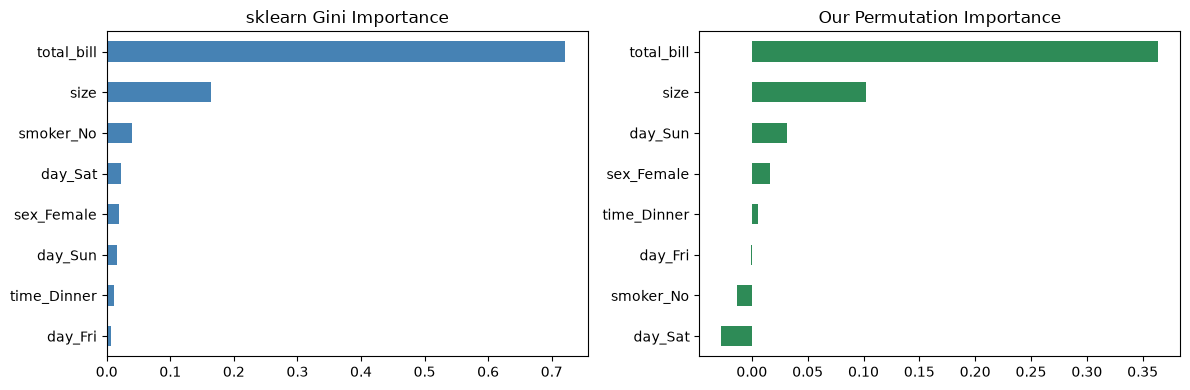

In [7]:
# sklearn's built-in importance
sk = RandomForestRegressor(n_estimators=200, max_depth=5, max_features=0.5,
                           oob_score=True, random_state=42).fit(X_tr, y_tr)
sk_imp = pd.Series(sk.feature_importances_, index=feature_names).sort_values(ascending=False)

# Permutation importance for our model
mine = MyRandomForestRegressor(n_estimators=200, max_depth=5, max_features=0.5,
                               random_state=42).fit(X_tr, y_tr)
baseline = r2_score(y_te, mine.predict(X_te))
perm_imp = {}

for j, feat in enumerate(feature_names):
    X_perm = X_te.copy()
    np.random.shuffle(X_perm[:, j])
    perm_r2 = r2_score(y_te, mine.predict(X_perm))
    perm_imp[feat] = baseline - perm_r2

mine_imp = pd.Series(perm_imp).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sk_imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('sklearn Gini Importance')
axes[0].invert_yaxis()
mine_imp.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Our Permutation Importance')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

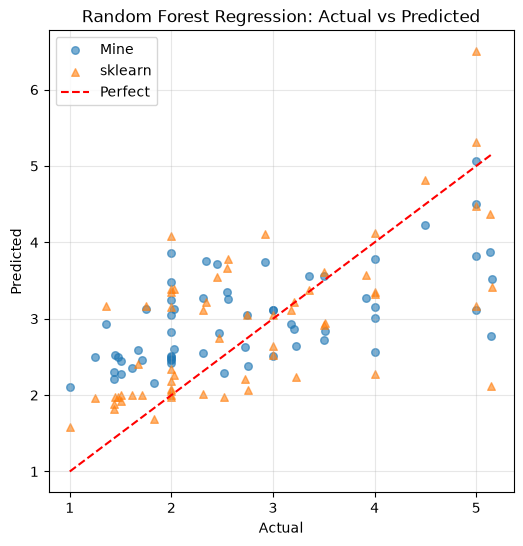

In [8]:
# Actual vs predicted scatter
plt.figure(figsize=(6, 6))
plt.scatter(y_te, pred_mine, alpha=0.6, s=30, label='Mine')
plt.scatter(y_te, pred_sk, alpha=0.6, s=30, marker='^', label='sklearn')
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', label='Perfect')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest Regression: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Summary & key takeaways

- Random Forest regression = **bagging** + **random feature subsets**, predicting the **mean** of trees.
- Bootstrap: ~63% unique rows in-bag per tree, ~37% OOB - free validation via `oob_score`.
- **Variance cancellation**: averaging uncorrelated tree errors shrinks variance while keeping low bias.
- `max_features` < 1.0 decorrelates trees; single trees vary wildly across seeds, forests are stable.
- **No extrapolation**: forest predictions flatten beyond training target range.
- Feature importance: Gini (sklearn) vs permutation (more reliable).
- Our implementation captures the core mechanics and matches sklearn's performance on real data.